In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import glob

# 找到所有CSV文件
path = '/content/drive/MyDrive/idx_dataset/'
files = glob.glob(path + 'CRMLSSold*.csv')

# 合并成一个dataframe
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(df.shape)
df.head()

/tmp/ipykernel_13006/1928895754.py:9: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
/tmp/ipykernel_13006/1928895754.py:9: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


(189608, 78)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,NorthSanLuisObispo,NorthSanLuisObispo,NaN,NaN,NaN,NaN,NaN,NaN,479293596,newlin@pacificaCRE.com,...,NaN,1807.0,NaN,NaN,NaN,NaN,93446,NaN,1807.0,NaN
1,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,NaN,12000.0,446914808,nleimers@hotmail.com,...,NaN,14253.0,NaN,False,NaN,NaN,92325,0.0,14253.0,NaN
2,SanDiego,SanDiego,Wood,True,NaN,NaN,False,1695.0,445176588,mannybehar@yahoo.com,...,NaN,NaN,NaN,NaN,0.0,NaN,92126,0.0,NaN,NaN
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,950000.0,1145282039,chase@cromwellhomegroup.com,...,NaN,NaN,NaN,False,2.0,NaN,91901,NaN,NaN,NaN
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,970000.0,1145278097,rory@corneliusestates.net,...,NaN,NaN,NaN,False,2.0,NaN,92115,NaN,NaN,NaN


In [ ]:
df = df[(df['PropertyType'] == 'Residential') &
        (df['PropertySubType'] == 'SingleFamilyResidence')]
print(df.shape)

(95196, 78)


In [ ]:
# 看有哪些列
print(df.columns.tolist())

# 看基本统计
df.describe()

['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDate', 'ElementarySchoolDist

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,9.499300e+04,9.519600e+04,9.519600e+04,95184.000000,95184.000000,95147.000000,9.519600e+04,95196.000000,0.0,0.0,...,0.0,681.000000,0.0,85168.000000,9.356700e+04,57887.000000,91502.000000,67604.000000,9.355800e+04,0.0
mean,1.374670e+06,1.137981e+09,1.343097e+06,34.730261,-118.586368,2055.066906,1.269466e+06,41.073175,NaN,NaN,...,NaN,65.731278,NaN,1.354523,1.843502e+04,2.259022,2.017644,107.880651,4.495698e+05,NaN
std,7.793322e+06,1.747771e+07,7.764911e+06,1.776839,3.366201,1041.751901,1.557639e+06,55.391498,NaN,NaN,...,NaN,275.204827,NaN,0.478371,1.767859e+05,1.437886,3.980500,351.112675,1.945697e+07,NaN
min,0.000000e+00,4.217759e+08,1.750000e+00,-22.863239,-124.175789,0.000000,8.000000e+03,-265.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,6.350000e+05,1.126016e+09,6.242055e+05,33.758188,-119.152458,1389.000000,6.250000e+05,8.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.400000e+03,1.000000,2.000000,0.000000,5.663000e+03,NaN
50%,8.990000e+05,1.144632e+09,8.900000e+05,34.082716,-118.025502,1825.000000,8.950000e+05,20.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.062000e+03,3.000000,2.000000,0.000000,7.280000e+03,NaN
75%,1.449000e+06,1.151952e+09,1.425000e+06,34.817881,-117.256665,2450.000000,1.399900e+06,53.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,9.936000e+03,3.000000,2.000000,133.000000,1.045400e+04,NaN
max,1.302000e+09,1.171669e+09,9.895000e+08,43.784440,120.432670,31068.000000,7.500000e+07,2177.000000,NaN,NaN,...,NaN,3490.000000,NaN,2.000000,3.164242e+07,44.000000,600.000000,20712.000000,1.938943e+09,NaN


In [ ]:
print(df.columns.tolist())

['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDate', 'ElementarySchoolDist

In [ ]:
df = df[(df['PropertyType'] == 'Residential') &
        (df['PropertySubType'] == 'SingleFamilyResidence')]
print(df.shape)

(95196, 78)


去掉异常值后数据量: (0, 127)


IndexError: index 0 is out of bounds for axis 0 with size 0

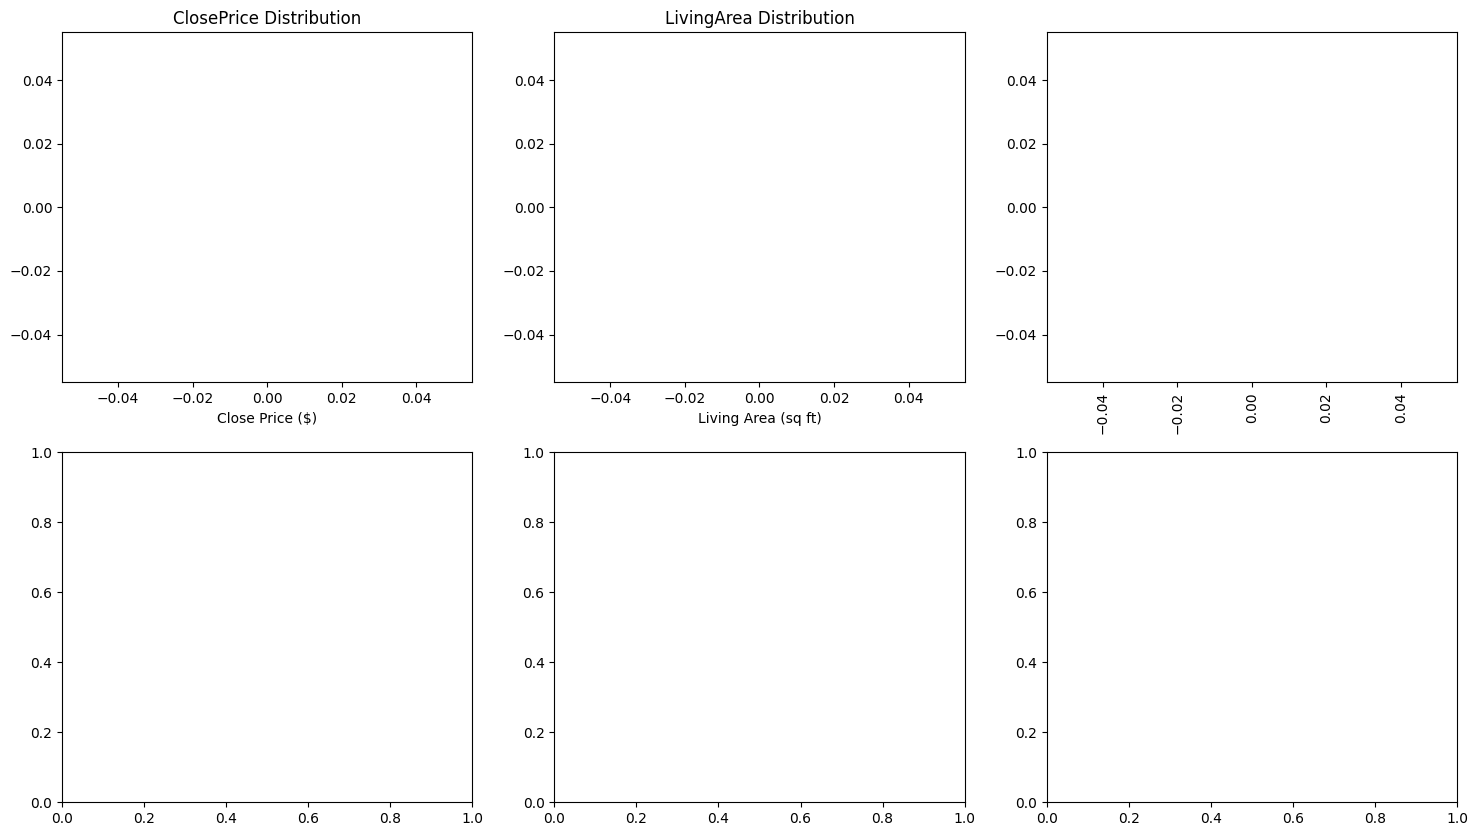

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = df[
    (df['ClosePrice'] > 100000) & (df['ClosePrice'] < 5000000) &
    (df['LivingArea'] > 200) & (df['LivingArea'] < 10000) &
    (df['LotSizeSquareFeet'] > 100) & (df['LotSizeSquareFeet'] < 100000)
]
print(f'去掉异常值后数据量: {df_clean.shape}')

# 画分布图
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ClosePrice
sns.histplot(df_clean['ClosePrice'].dropna(), bins=50, ax=axes[0,0])
axes[0,0].set_title('ClosePrice Distribution')
axes[0,0].set_xlabel('Close Price ($)')

# LivingArea
sns.histplot(df_clean['LivingArea'].dropna(), bins=50, ax=axes[0,1])
axes[0,1].set_title('LivingArea Distribution')
axes[0,1].set_xlabel('Living Area (sq ft)')

# Bedrooms
df_clean['BedroomsTotal'].value_counts().sort_index().plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('Bedrooms Distribution')
axes[0,2].set_xlabel('Number of Bedrooms')

# Bathrooms
df_clean['BathroomsTotalInteger'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Bathrooms Distribution')
axes[1,0].set_xlabel('Number of Bathrooms')

# LotSize
sns.histplot(df_clean['LotSizeSquareFeet'].dropna(), bins=50, ax=axes[1,1])
axes[1,1].set_title('LotSize Distribution')
axes[1,1].set_xlabel('Lot Size (sq ft)')

# DaysOnMarket
sns.histplot(df_clean['DaysOnMarket'].dropna(), bins=50, ax=axes[1,2])
axes[1,2].set_title('Days on Market Distribution')
axes[1,2].set_xlabel('Days on Market')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

In [ ]:
!pwd
!ls

/content/idx-exchange-project
eda_plots.png  idx_project.ipynb  README.md


In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   idx_project.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	eda_plots.png



In [57]:
# 1. 挂载Google Drive（如果还没挂载）
from google.colab import drive
drive.mount('/content/drive')

# 2. 输入token（不会保存到文件）
import getpass
token = getpass.getpass("输入你的GitHub Token: ")

# 3. Clone repo
%cd /content
!git clone https://{token}@github.com/rongweishen63-blip/idx-exchange-project.git
%cd idx-exchange-project

# 4. 复制notebook
!cp "/content/drive/MyDrive/Colab Notebooks/idx_project.ipynb" .

# 5. Push
!git config --global user.email "rongweishen63@gmail.com"
!git config --global user.name "rongweishen63-blip"

!cp "/content/drive/MyDrive/Colab Notebooks/02_preprocessing.ipynb" .

!git add .
!git commit -m "更新EDA"
!git push origin main

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
输入你的GitHub Token: ··········
/content
fatal: destination path 'idx-exchange-project' already exists and is not an empty directory.
/content/idx-exchange-project
[main 2ce5e55] 更新EDA
 3 files changed, 2 insertions(+), 1 deletion(-)
 create mode 100644 02_preprocessing.ipynb
 create mode 100644 eda_plots.png
 rewrite idx_project.ipynb (96%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 284.34 KiB | 8.12 MiB/s, done.
Total 5 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/rongweishen63-blip/idx-exchange-project.git
   190a2d1..2ce5e55  main -> main


In [ ]:
missing_pct = df.isnull().mean().sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

TaxAnnualAmount             1.000000
AboveGradeFinishedArea      1.000000
FireplacesTotal             1.000000
TaxYear                     1.000000
ElementarySchoolDistrict    1.000000
                              ...   
PurchaseContractDate        0.000063
ListAgentLastName           0.000063
BathroomsTotalInteger       0.000053
ParkingTotal                0.000011
PostalCode                  0.000011
Length: 61, dtype: float64


In [ ]:
pd.set_option('display.max_rows', None)
print(missing_pct[missing_pct > 0])

TaxAnnualAmount                 1.000000
AboveGradeFinishedArea          1.000000
FireplacesTotal                 1.000000
TaxYear                         1.000000
ElementarySchoolDistrict        1.000000
BusinessType                    1.000000
CoveredSpaces                   1.000000
MiddleOrJuniorSchoolDistrict    1.000000
WaterfrontYN                    0.999433
BelowGradeFinishedArea          0.992846
BasementYN                      0.975398
BuilderName                     0.953759
LotSizeDimensions               0.937371
BuildingAreaTotal               0.933380
CoBuyerAgentFirstName           0.905983
ElementarySchool                0.871770
MiddleOrJuniorSchool            0.870803
HighSchool                      0.830781
CoListAgentFirstName            0.765368
CoListAgentLastName             0.764570
CoListOfficeName                0.742752
AssociationFeeFrequency         0.742668
SubdivisionName                 0.644859
MainLevelBedrooms               0.391918
Flooring        

In [ ]:
df['Flooring_missing'] = df['Flooring'].isnull().astype(int)
df['Flooring'] = df['Flooring'].fillna('Unknown')

In [ ]:
# 第一、二、三段：直接删除
cols_to_drop = [
    'TaxAnnualAmount', 'AboveGradeFinishedArea', 'FireplacesTotal', 'TaxYear',
    'ElementarySchoolDistrict', 'BusinessType', 'CoveredSpaces', 'MiddleOrJuniorSchoolDistrict',
    'WaterfrontYN', 'BelowGradeFinishedArea', 'BasementYN', 'BuilderName',
    'LotSizeDimensions', 'BuildingAreaTotal', 'CoBuyerAgentFirstName',
    'ElementarySchool', 'MiddleOrJuniorSchool', 'HighSchool',
    'CoListAgentFirstName', 'CoListAgentLastName', 'CoListOfficeName', 'AssociationFeeFrequency'
]
df = df.drop(columns=cols_to_drop)

# 第五段：加 flag + 填 Unknown
for col in ['MainLevelBedrooms', 'Flooring']:
    df[col + '_missing'] = df[col].isnull().astype(int)
    df[col] = df[col].fillna('Unknown')

# 第六段：数值列填中位数
numeric_fill_cols = ['GarageSpaces', 'LotSizeSquareFeet', 'LotSizeAcres', 'LotSizeArea', 'Stories', 'AssociationFee']
for col in numeric_fill_cols:
    df[col] = df[col].fillna(df[col].median())

# 第六段：类别/布尔列填众数或Unknown
cat_fill_cols = ['ViewYN', 'PoolPrivateYN', 'NewConstructionYN', 'AttachedGarageYN',
                  'HighSchoolDistrict', 'MLSAreaMajor', 'BuyerOfficeAOR', 'BuyerAgentAOR',
                  'BuyerOfficeName', 'Levels']
for col in cat_fill_cols:
    df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown')

# 检查还有没有缺失
print(df.isnull().sum().sort_values(ascending=False).head(10))

/tmp/ipykernel_13006/4030519380.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown')


SubdivisionName        61388
ListAgentFirstName       600
BuyerAgentFirstName      424
ListAgentEmail           228
OriginalListPrice        203
BuyerAgentMlsId          145
StreetNumberNumeric      129
UnparsedAddress          108
FireplaceYN               82
BuyerAgentLastName        69
dtype: int64


In [ ]:
df['SubdivisionName_missing'] = df['SubdivisionName'].isnull().astype(int)
df['SubdivisionName'] = df['SubdivisionName'].fillna('Unknown')

In [ ]:
df = df.drop(columns=['ListAgentFirstName', 'BuyerAgentFirstName', 'ListAgentEmail', 'BuyerAgentMlsId', 'BuyerAgentLastName'])

In [ ]:
df['OriginalListPrice'] = df['OriginalListPrice'].fillna(df['OriginalListPrice'].median())

In [ ]:
df = df.drop(columns=['StreetNumberNumeric', 'UnparsedAddress'])

In [ ]:
df['FireplaceYN'] = df['FireplaceYN'].fillna(df['FireplaceYN'].mode()[0])

/tmp/ipykernel_13006/1847081562.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['FireplaceYN'] = df['FireplaceYN'].fillna(df['FireplaceYN'].mode()[0])


In [ ]:
print(df.isnull().sum().sort_values(ascending=False).head(10))

YearBuilt                57
LivingArea               49
ListAgentFullName        37
ListAgentAOR             21
Latitude                 12
Longitude                12
PurchaseContractDate      6
ListAgentLastName         6
BathroomsTotalInteger     5
ParkingTotal              1
dtype: int64


In [ ]:
# 删除经纪人字段
df = df.drop(columns=['ListAgentFullName', 'ListAgentAOR', 'ListAgentLastName'])

# 数值列填中位数
for col in ['YearBuilt', 'LivingArea', 'BathroomsTotalInteger', 'ParkingTotal']:
    df[col] = df[col].fillna(df[col].median())

# 缺失量极少的行，直接删除
df = df.dropna(subset=['Latitude', 'Longitude', 'PurchaseContractDate'])

# 最终检查
print(df.isnull().sum().sum())  # 应该输出 0

1


In [ ]:
# ========== 排查剩余的1个缺失值 ==========
print(df.isnull().sum()[df.isnull().sum() > 0])

PostalCode    1
dtype: int64


In [ ]:
df = df.dropna(subset=['PostalCode'])

In [ ]:
print(df.isnull().sum().sum())

0


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)
print(len(categorical_cols))

['BuyerAgentAOR', 'Flooring', 'CloseDate', 'ListOfficeName', 'BuyerOfficeName', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus', 'PropertySubType', 'SubdivisionName', 'BuyerOfficeAOR', 'ListingId', 'ContractStatusChangeDate', 'PurchaseContractDate', 'ListingContractDate', 'StateOrProvince', 'Levels', 'MainLevelBedrooms', 'HighSchoolDistrict', 'PostalCode']
20


In [ ]:
for col in categorical_cols:
    print(col, '-> 类别数:', df[col].nunique())

BuyerAgentAOR -> 类别数: 55
Flooring -> 类别数: 256
CloseDate -> 类别数: 271
ListOfficeName -> 类别数: 9589
BuyerOfficeName -> 类别数: 10464
MLSAreaMajor -> 类别数: 1007
CountyOrParish -> 类别数: 60
MlsStatus -> 类别数: 1
PropertySubType -> 类别数: 1
SubdivisionName -> 类别数: 6682
BuyerOfficeAOR -> 类别数: 57
ListingId -> 类别数: 95116
ContractStatusChangeDate -> 类别数: 271
PurchaseContractDate -> 类别数: 557
ListingContractDate -> 类别数: 838
StateOrProvince -> 类别数: 4
Levels -> 类别数: 18
MainLevelBedrooms -> 类别数: 23
HighSchoolDistrict -> 类别数: 409
PostalCode -> 类别数: 1885


In [ ]:

# 1. 删除没有区分度 / 跟房价无关的类别列
df = df.drop(columns=[
    'MlsStatus', 'PropertySubType',
    'BuyerAgentAOR', 'BuyerOfficeAOR',
    'ListOfficeName', 'BuyerOfficeName',
    'ListingId'
])

# 2. 转成日期类型（不做编码）
date_cols = ['CloseDate', 'ContractStatusChangeDate', 'PurchaseContractDate', 'ListingContractDate']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# 3. 高基数列：删除（方案A，简单快速）
df = df.drop(columns=['MLSAreaMajor', 'SubdivisionName', 'HighSchoolDistrict', 'PostalCode'])

# 4. 类别数适中的列：One-Hot 编码
onehot_cols = ['CountyOrParish', 'StateOrProvince', 'Levels', 'MainLevelBedrooms', 'Flooring']
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

# 5. 检查结果
print(df.shape)
print(df.dtypes.value_counts())

(95177, 1347)
bool              1321
float64             16
int64                6
datetime64[ns]       4
Name: count, dtype: int64


In [ ]:
# 删除之前 Flooring One-Hot 生成的所有列
flooring_cols = [col for col in df.columns if col.startswith('Flooring_')]
df = df.drop(columns=flooring_cols)

print(df.shape)  # 应该会大幅降回合理范围
print(df.dtypes.value_counts())

(95177, 1091)
bool              1066
float64             16
int64                5
datetime64[ns]       4
Name: count, dtype: int64


In [ ]:
bool_cols = df.select_dtypes(include='bool').columns.tolist()
# 统计每种前缀出现了多少次
import re
prefixes = [col.split('_')[0] for col in bool_cols]
from collections import Counter
print(Counter(prefixes))

Counter({'City': 960, 'CountyOrParish': 59, 'MainLevelBedrooms': 22, 'Levels': 17, 'StateOrProvince': 3, 'ViewYN': 1, 'PoolPrivateYN': 1, 'AttachedGarageYN': 1, 'FireplaceYN': 1, 'NewConstructionYN': 1})


In [ ]:
# 删除 City 的 One-Hot 列
city_cols = [col for col in df.columns if col.startswith('City_')]
df = df.drop(columns=city_cols)

print(df.shape)
print(df.dtypes.value_counts())

bool_cols = df.select_dtypes(include='bool').columns.tolist()
prefixes = [col.split('_')[0] for col in bool_cols]
from collections import Counter
print(Counter(prefixes))

(95177, 131)
bool              106
float64            16
int64               5
datetime64[ns]      4
Name: count, dtype: int64
Counter({'CountyOrParish': 59, 'MainLevelBedrooms': 22, 'Levels': 17, 'StateOrProvince': 3, 'ViewYN': 1, 'PoolPrivateYN': 1, 'AttachedGarageYN': 1, 'FireplaceYN': 1, 'NewConstructionYN': 1})


In [ ]:
print(df.select_dtypes(include=['float64', 'int64']).columns.tolist())

['OriginalListPrice', 'ListingKey', 'ClosePrice', 'Latitude', 'Longitude', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListingKeyNumeric', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt', 'BathroomsTotalInteger', 'BedroomsTotal', 'Stories', 'LotSizeArea', 'GarageSpaces', 'AssociationFee', 'LotSizeSquareFeet', 'MainLevelBedrooms_missing', 'SubdivisionName_missing']


In [ ]:
df = df.drop(columns=['ListingKey', 'ListingKeyNumeric'])
numeric_all = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
for col in numeric_all:
    print(col)

OriginalListPrice
ClosePrice
Latitude
Longitude
LivingArea
ListPrice
DaysOnMarket
ParkingTotal
LotSizeAcres
YearBuilt
BathroomsTotalInteger
BedroomsTotal
Stories
LotSizeArea
GarageSpaces
AssociationFee
LotSizeSquareFeet
MainLevelBedrooms_missing
SubdivisionName_missing


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. 目标变量单独拿出来
target_col = 'ClosePrice'

# 2. 去掉冗余的地块大小字段，只保留一个
df = df.drop(columns=['LotSizeAcres', 'LotSizeArea'])

# 3. 对右偏严重的数值列做 log 变换（根据你之前EDA图，LivingArea/LotSize都右偏）
skewed_cols = ['LivingArea', 'LotSizeSquareFeet']
for col in skewed_cols:
    df[col] = np.log1p(df[col])

# 4. 定义最终要归一化的特征列
numeric_cols = [
    'Latitude', 'Longitude', 'LivingArea', 'DaysOnMarket',
    'ParkingTotal', 'YearBuilt', 'BathroomsTotalInteger',
    'BedroomsTotal', 'Stories', 'GarageSpaces',
    'AssociationFee', 'LotSizeSquareFeet'
]

# 5. 归一化
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print(df[numeric_cols].describe())

           Latitude     Longitude    LivingArea  DaysOnMarket  ParkingTotal  \
count  9.517700e+04  9.517700e+04  9.517700e+04  9.517700e+04  9.517700e+04   
mean  -2.687576e-16 -1.030835e-14  1.682422e-15 -6.689077e-17 -4.329983e-18   
std    1.000005e+00  1.000005e+00  1.000005e+00  1.000005e+00  1.000005e+00   
min   -3.241339e+01 -1.660395e+00 -3.428704e+01 -5.525538e+00 -1.156204e+00   
25%   -5.470557e-01 -1.681576e-01 -5.305749e-01 -5.971145e-01 -5.973444e-02   
50%   -3.644459e-01  1.666362e-01 -1.035593e-02 -3.804805e-01 -5.973444e-02   
75%    4.936215e-02  3.950280e-01  5.340188e-01  2.152630e-01  1.180512e-03   
max    5.095643e+00  7.100417e+01  4.591254e+00  3.855948e+01  2.386660e+02   

          YearBuilt  BathroomsTotalInteger  BedroomsTotal       Stories  \
count  9.517700e+04           9.517700e+04   9.517700e+04  9.517700e+04   
mean  -2.759244e-15           1.612545e-16   8.958585e-17  4.240397e-17   
std    1.000005e+00           1.000005e+00   1.000005e+00  1.00

In [54]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ===== 1. 确认 CloseDate 是 datetime 类型 =====
df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# ===== 2. 确定测试集：最新一个月 =====
max_date = df['CloseDate'].max()
test_start = max_date - pd.DateOffset(months=1)

test_set = df[df['CloseDate'] >= test_start].copy()
print(f"最新日期: {max_date}")
print(f"测试集起始: {test_start}")
print(f"测试集样本数: {len(test_set)}")

# ===== 3. 准备特征列和目标变量 =====
target_col = 'ClosePrice'
exclude_cols = ['ClosePrice', 'ListPrice', 'OriginalListPrice', 'CloseDate',
                 'ContractStatusChangeDate', 'PurchaseContractDate', 'ListingContractDate']
feature_cols = [col for col in df.columns if col not in exclude_cols]

# ===== 4. 实验不同的训练窗口长度 X =====
results = []

for X in [3, 6, 12, 18, 24, 36]:
    train_start = test_start - pd.DateOffset(months=X)
    train_set = df[(df['CloseDate'] >= train_start) & (df['CloseDate'] < test_start)].copy()

    if len(train_set) < 100:  # 数据太少就跳过
        print(f"X={X}: 训练样本不足({len(train_set)})，跳过")
        continue

    X_train = train_set[feature_cols]
    y_train = train_set[target_col]
    X_test = test_set[feature_cols]
    y_test = test_set[target_col]

    # 用一个简单快速的模型做对比实验（后续正式建模可以换成更复杂的模型）
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        'X_months': X,
        'train_samples': len(train_set),
        'MAE': mae,
        'RMSE': rmse
    })
    print(f"X={X}个月: 训练样本={len(train_set)}, MAE={mae:.2f}, RMSE={rmse:.2f}")

# ===== 5. 汇总结果，找最优 X =====
results_df = pd.DataFrame(results)
print(results_df)

best_X = results_df.loc[results_df['RMSE'].idxmin(), 'X_months']
print(f"\n最优训练窗口长度 X = {best_X} 个月")

最新日期: 2026-05-31 00:00:00
测试集起始: 2026-04-30 00:00:00
测试集样本数: 12465
X=3个月: 训练样本=31745, MAE=423284.28, RMSE=3522120.32
X=6个月: 训练样本=59873, MAE=388404.82, RMSE=3750429.08
X=12个月: 训练样本=82712, MAE=352301.24, RMSE=3525227.53
X=18个月: 训练样本=82712, MAE=352301.24, RMSE=3525227.53
X=24个月: 训练样本=82712, MAE=352301.24, RMSE=3525227.53
X=36个月: 训练样本=82712, MAE=352301.24, RMSE=3525227.53
   X_months  train_samples            MAE          RMSE
0         3          31745  423284.275998  3.522120e+06
1         6          59873  388404.820247  3.750429e+06
2        12          82712  352301.238536  3.525228e+06
3        18          82712  352301.238536  3.525228e+06
4        24          82712  352301.238536  3.525228e+06
5        36          82712  352301.238536  3.525228e+06

最优训练窗口长度 X = 3 个月


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31383 (\N{CJK UNIFIED IDEOGRAPH-7A97}) missing from font(s) DejaVu Sans.
  fig.canvas

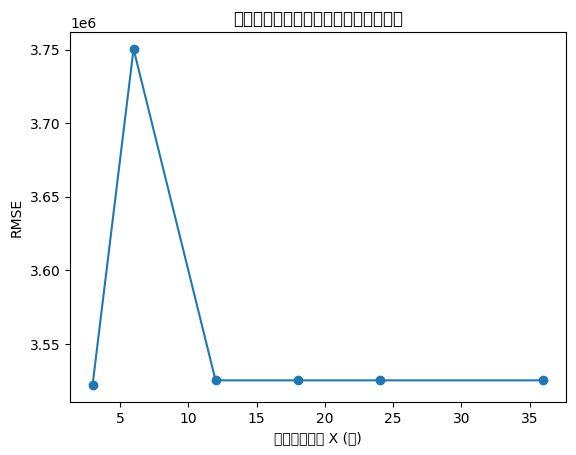

In [55]:
import matplotlib.pyplot as plt

plt.plot(results_df['X_months'], results_df['RMSE'], marker='o')
plt.xlabel('训练窗口长度 X (月)')
plt.ylabel('RMSE')
plt.title('不同训练窗口长度对测试集误差的影响')
plt.show()